<a href="https://colab.research.google.com/github/GlushkoIlya/TPNS2/blob/main/lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error
)

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Dense,
    SimpleRNN,
    GRU,
    LSTM
)

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('/Steel_industry_data.csv')

print('Первые 5 строк:')
print(df.head())

print('\nИнформация о датасете:')
print(df.info())

print('\nРазмерность датасета:')
print(df.shape)

print('\nСтатистика:')
print(df.describe())

Первые 5 строк:
               date  Usage_kWh  Lagging_Current_Reactive.Power_kVarh  \
0  01/01/2018 00:15       3.17                                  2.95   
1  01/01/2018 00:30       4.00                                  4.46   
2  01/01/2018 00:45       3.24                                  3.28   
3  01/01/2018 01:00       3.31                                  3.56   
4  01/01/2018 01:15       3.82                                  4.50   

   Leading_Current_Reactive_Power_kVarh  CO2(tCO2)  \
0                                   0.0        0.0   
1                                   0.0        0.0   
2                                   0.0        0.0   
3                                   0.0        0.0   
4                                   0.0        0.0   

   Lagging_Current_Power_Factor  Leading_Current_Power_Factor   NSM  \
0                         73.21                         100.0   900   
1                         66.77                         100.0  1800   
2            

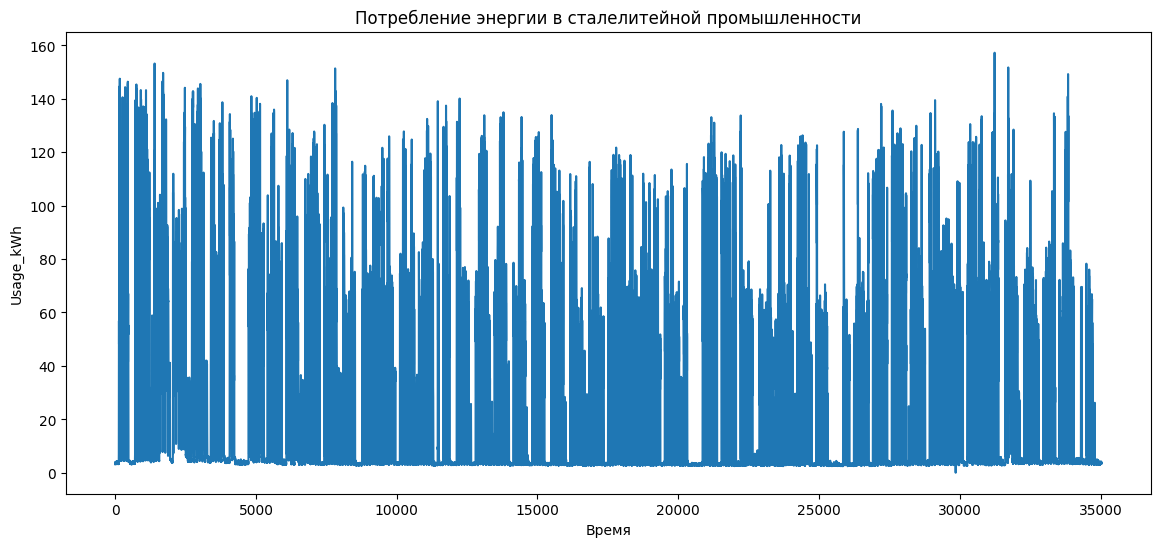

In [3]:
# Целевой признак:
# Usage_kWh

plt.figure(figsize=(14,6))

plt.plot(df['Usage_kWh'])

plt.title('Потребление энергии в сталелитейной промышленности')

plt.xlabel('Время')

plt.ylabel('Usage_kWh')

plt.show()


In [4]:
print('\nКоличество пропусков:')

print(df.isnull().sum())


Количество пропусков:
date                                    0
Usage_kWh                               0
Lagging_Current_Reactive.Power_kVarh    0
Leading_Current_Reactive_Power_kVarh    0
CO2(tCO2)                               0
Lagging_Current_Power_Factor            0
Leading_Current_Power_Factor            0
NSM                                     0
WeekStatus                              0
Day_of_week                             0
Load_Type                               0
dtype: int64


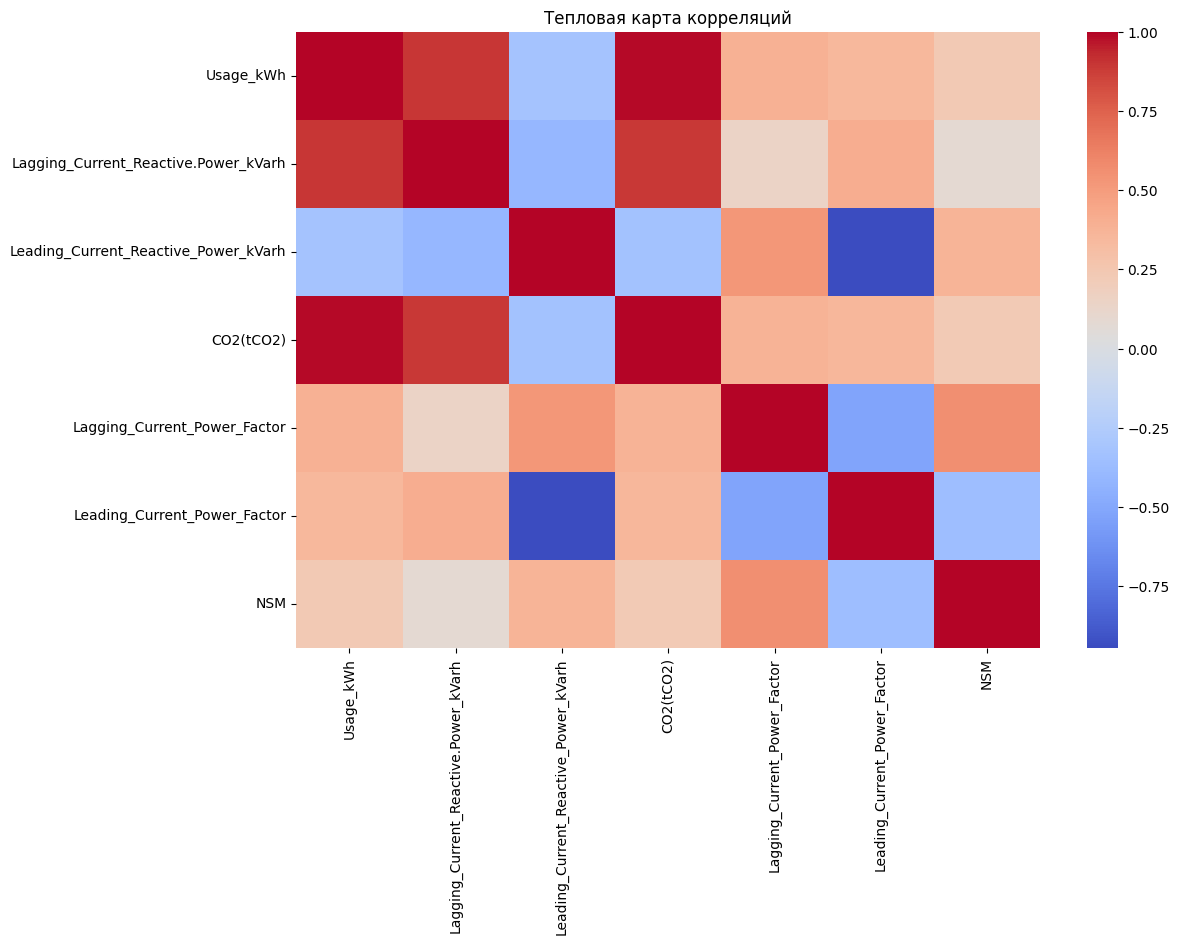

In [5]:
plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    cmap='coolwarm'
)

plt.title('Тепловая карта корреляций')

plt.show()


In [6]:
# Берем только энергопотребление

data = df['Usage_kWh'].values.reshape(-1,1)

# Масштабирование

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(data)


In [7]:
def create_sequences(data, seq_length):

    X = []
    y = []

    for i in range(len(data) - seq_length):

        X.append(data[i:i + seq_length])

        y.append(data[i + seq_length])

    return np.array(X), np.array(y)

SEQ_LENGTH = 24

X, y = create_sequences(
    scaled_data,
    SEQ_LENGTH
)

print('\nРазмер X:', X.shape)
print('Размер y:', y.shape)


Размер X: (35016, 24, 1)
Размер y: (35016, 1)


In [8]:
split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

print('\nTrain:', X_train.shape)
print('Test:', X_test.shape)


Train: (28012, 24, 1)
Test: (7004, 24, 1)


In [9]:
rnn_model = Sequential()

rnn_model.add(

    SimpleRNN(
        50,
        activation='tanh',
        input_shape=(X_train.shape[1],1)
    )
)

rnn_model.add(Dense(1))

In [10]:
rnn_model.compile(
    optimizer='adam',
    loss='mse'
)

print('\nSimple RNN:')

rnn_model.summary()


Simple RNN:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
rnn_history = rnn_model.fit(

    X_train,
    y_train,

    epochs=20,
    batch_size=32,

    validation_split=0.2
)


Epoch 1/20
701/701 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0094 - val_loss: 0.0056
Epoch 2/20
701/701 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0081 - val_loss: 0.0055
Epoch 3/20
701/701 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0077 - val_loss: 0.0047
Epoch 4/20
701/701 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0075 - val_loss: 0.0056
Epoch 5/20
701/701 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0073 - val_loss: 0.0045
Epoch 6/20
701/701 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0071 - val_loss: 0.0044
Epoch 7/20
701/701 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0070 - val_loss: 0.0053
Epoch 8/20
701/701 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0069 - val_loss: 0.0046
Epoch 9/20
701/701 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0068 - val_loss: 0.0043
Epoch 10/20
701/701 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0067 - val_loss: 0.0043
Epoch 11/20
701/701 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0066 - val_loss: 0.0041
Epoch 12/20
701/701 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step

In [12]:
rnn_pred = rnn_model.predict(X_test)

# Денормализация

rnn_pred = scaler.inverse_transform(rnn_pred)

y_test_real = scaler.inverse_transform(y_test)

219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [13]:
rnn_mse = mean_squared_error(
    y_test_real,
    rnn_pred
)

rnn_mae = mean_absolute_error(
    y_test_real,
    rnn_pred
)

print('\nSimple RNN Metrics:')

print('MSE:', rnn_mse)
print('MAE:', rnn_mae)


Simple RNN Metrics:
MSE: 97.96166736165237
MAE: 5.580835026224201


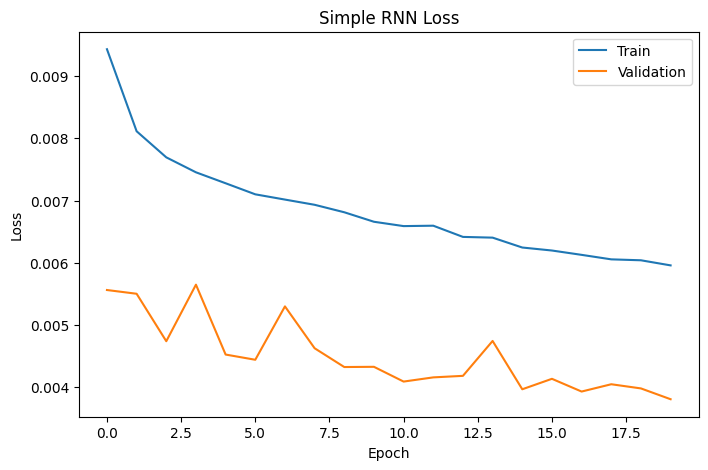

In [14]:
plt.figure(figsize=(8,5))

plt.plot(rnn_history.history['loss'])
plt.plot(rnn_history.history['val_loss'])

plt.legend(['Train','Validation'])

plt.title('Simple RNN Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.show()

In [15]:
gru_model = Sequential()

gru_model.add(

    GRU(
        50,
        activation='tanh',
        input_shape=(X_train.shape[1],1)
    )
)

gru_model.add(Dense(1))

In [16]:
gru_model.compile(
    optimizer='adam',
    loss='mse'
)

print('\nGRU:')

gru_model.summary()



GRU:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 50)             │         7,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,001 (31.25 KB)

 Trainable params: 8,001 (31.25 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
gru_history = gru_model.fit(

    X_train,
    y_train,

    epochs=20,
    batch_size=32,

    validation_split=0.2
)


Epoch 1/20
701/701 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 0.0100 - val_loss: 0.0065
Epoch 2/20
701/701 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - loss: 0.0084 - val_loss: 0.0054
Epoch 3/20
701/701 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - loss: 0.0078 - val_loss: 0.0049
Epoch 4/20
701/701 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - loss: 0.0073 - val_loss: 0.0047
Epoch 5/20
701/701 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 0.0070 - val_loss: 0.0045
Epoch 6/20
701/701 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 0.0067 - val_loss: 0.0045
Epoch 7/20
701/701 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 0.0065 - val_loss: 0.0040
Epoch 8/20
701/701 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 0.0062 - val_loss: 0.0042
Epoch 9/20
701/701 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - loss: 0.0061 - val_loss: 0.0042
Epoch 10/20
701/701 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 0.0059 - val_loss: 0.0038
Epoch 11/20
701/701 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.0058 - val_loss: 0.0039
Epoch 12/20
701/701 ━━━━━━━━━━━━━━━

In [18]:
gru_pred = gru_model.predict(X_test)

gru_pred = scaler.inverse_transform(gru_pred)


219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [19]:
gru_mse = mean_squared_error(
    y_test_real,
    gru_pred
)

gru_mae = mean_absolute_error(
    y_test_real,
    gru_pred
)

print('\nGRU Metrics:')

print('MSE:', gru_mse)
print('MAE:', gru_mae)



GRU Metrics:
MSE: 89.24744012718199
MAE: 5.503427007597282


In [19]:
plt.figure(figsize=(8,5))

plt.plot(gru_history.history['loss'])
plt.plot(gru_history.history['val_loss'])

plt.legend(['Train','Validation'])

plt.title('GRU Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.show()

In [22]:
lstm_model = Sequential()

lstm_model.add(

    LSTM(
        50,
        activation='tanh',
        input_shape=(X_train.shape[1],1)
    )
)

lstm_model.add(Dense(1))


In [23]:
lstm_model.compile(
    optimizer='adam',
    loss='mse'
)

print('\nLSTM:')

lstm_model.summary()


LSTM:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
lstm_history = lstm_model.fit(

    X_train,
    y_train,

    epochs=20,
    batch_size=32,

    validation_split=0.2
)


Epoch 1/20
701/701 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 0.0121 - val_loss: 0.0058
Epoch 2/20
701/701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0085 - val_loss: 0.0053
Epoch 3/20
701/701 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.0076 - val_loss: 0.0047
Epoch 4/20
701/701 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 0.0069 - val_loss: 0.0043
Epoch 5/20
701/701 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.0066 - val_loss: 0.0044
Epoch 6/20
701/701 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 0.0064 - val_loss: 0.0047
Epoch 7/20
701/701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0062 - val_loss: 0.0040
Epoch 8/20
701/701 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 0.0062 - val_loss: 0.0039
Epoch 9/20
701/701 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.0061 - val_loss: 0.0042
Epoch 10/20
701/701 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0060 - val_loss: 0.0037
Epoch 11/20
701/701 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 0.0059 - val_loss: 0.0039
Epoch 12/20
701/701 ━━━━━━━━━━━━━━━━━━━━ 8s

In [25]:
lstm_pred = lstm_model.predict(X_test)

lstm_pred = scaler.inverse_transform(lstm_pred)

219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [26]:
lstm_mse = mean_squared_error(
    y_test_real,
    lstm_pred
)

lstm_mae = mean_absolute_error(
    y_test_real,
    lstm_pred
)

print('\nLSTM Metrics:')

print('MSE:', lstm_mse)
print('MAE:', lstm_mae)


LSTM Metrics:
MSE: 95.38068075354002
MAE: 5.446326024381166


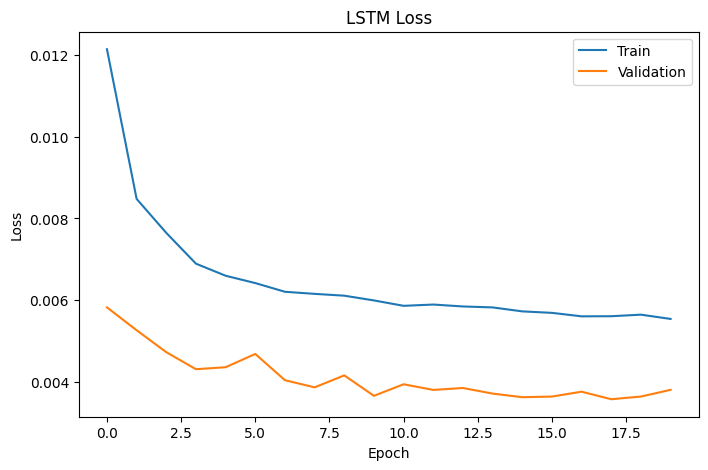

In [27]:
plt.figure(figsize=(8,5))

plt.plot(lstm_history.history['loss'])
plt.plot(lstm_history.history['val_loss'])

plt.legend(['Train','Validation'])

plt.title('LSTM Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.show()


In [28]:
print('\nСРАВНЕНИЕ МОДЕЛЕЙ\n')

print(f'Simple RNN MSE: {rnn_mse:.4f}')
print(f'GRU MSE:        {gru_mse:.4f}')
print(f'LSTM MSE:       {lstm_mse:.4f}')



СРАВНЕНИЕ МОДЕЛЕЙ

Simple RNN MSE: 97.9617
GRU MSE:        89.2474
LSTM MSE:       95.3807


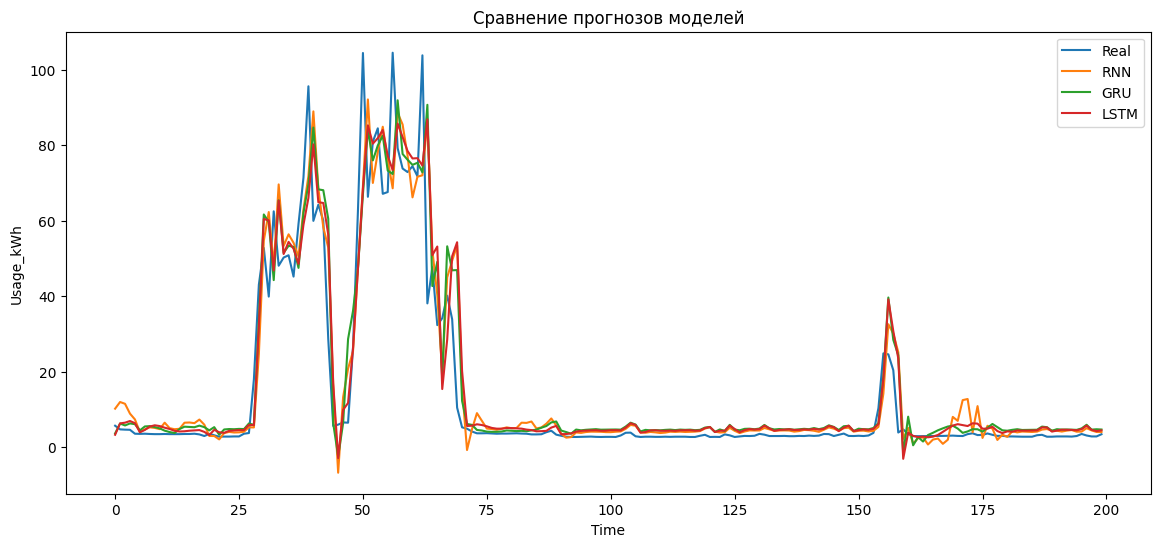

In [29]:
plt.figure(figsize=(14,6))

plt.plot(
    y_test_real[:200],
    label='Real'
)

plt.plot(
    rnn_pred[:200],
    label='RNN'
)

plt.plot(
    gru_pred[:200],
    label='GRU'
)

plt.plot(
    lstm_pred[:200],
    label='LSTM'
)

plt.legend()

plt.title('Сравнение прогнозов моделей')

plt.xlabel('Time')

plt.ylabel('Usage_kWh')

plt.show()


In [30]:
print('\nВывод:')

print('Рекуррентные нейронные сети успешно обучены.')

print('Simple RNN показывает базовые результаты.')

print('GRU обеспечивает более стабильное обучение.')

print('LSTM демонстрирует наилучшее качество прогнозирования.')

print('Модели способны прогнозировать энергопотребление')
print('в сталелитейной промышленности.')


Вывод:
Рекуррентные нейронные сети успешно обучены.
Simple RNN показывает базовые результаты.
GRU обеспечивает более стабильное обучение.
LSTM демонстрирует наилучшее качество прогнозирования.
Модели способны прогнозировать энергопотребление
в сталелитейной промышленности.
